# Model definition and evaluation

This notebook implements and compares three models to improve on the
watershed baseline (DICE = 0.0006) from `2_BaselineModel/`.
All models are evaluated on the same 200-image balanced validation split.

## Reference: watershed baseline

The watershed baseline from `2_BaselineModel/` scores a mean DICE of **0.0006** on the
200-image balanced validation split. Every model in this notebook is evaluated on the
same split for a fair comparison.

| Metric | Watershed baseline | This model |
|---|---|---|
| Mean DICE (val, 200 images) | 0.0006 | TBD |
| Lowest-DICE class | Class 1 (0.0000) | TBD |
| Highest-DICE class | Class 24 (0.0084) | TBD |

This table will be updated after training.

## 1. Model selection

Three models of increasing sophistication were chosen:

| Model | Type | Key idea |
|---|---|---|
| K-Means (k=10) | Unsupervised clustering | Extend watershed by adding spatial features; no training needed |
| ShallowSegNet | Supervised 3-layer CNN | Learn organ appearance from labelled images; minimal architecture |
| U-Net | Supervised encoder-decoder | Skip connections preserve spatial detail; standard for medical segmentation |

**Rationale for progression:** each step adds exactly one new capability —
spatial awareness (K-Means), supervised learning (ShallowSegNet), and
multi-scale context with skip connections (U-Net). This makes the effect
of each addition measurable and interpretable.

## 2. Feature engineering

**K-Means:** pixel features = `[normalised intensity, x/W, y/H]`.
Spatial coordinates prevent merging spatially distant regions of similar
intensity (e.g. body-exterior air and pulmonary air), which was the main
failure of watershed.

**ShallowSegNet and U-Net:** input = single-channel 128×128 grayscale image,
normalised to [0, 1]. No handcrafted features — convolutional layers learn
relevant filters directly. Images are downsampled from 256×256 for CPU speed.

**Class weights:** inverse-frequency weights in the cross-entropy loss.
Computed from the balanced training subset so rare organs receive a
proportionally larger gradient signal.

## 3. Hyperparameter tuning

Hyperparameters were set manually based on CPU constraints and standard
practice for small medical imaging datasets. No automated search was
performed.

| Hyperparameter | K-Means | ShallowSegNet | U-Net |
|---|---|---|---|
| Input resolution | 256×256 | 128×128 | 128×128 |
| Clusters / classes | 10 | 55 | 55 |
| Learning rate | — | 1e-3 (Adam) | 1e-3 (Adam) |
| LR schedule | — | None | StepLR ×0.5 / 10 epochs |
| Epochs | — | 10 | 20 |
| Batch size | — | 8 | 8 |
| Loss | — | CrossEntropy (weighted) | CrossEntropy (weighted) |
| num_workers | — | 0 (Windows) | 0 (Windows) |

In [2]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
# Tuned for CPU-only training on a typical 4–8 core laptop.
# Expect ~5 min for ShallowSegNet, ~20 min for U-Net.
# To go faster: reduce IMG_SIZE to 64 or EPOCHS_* to 5.
#
# Note: torch.compile() is disabled on Windows CPU (requires MSVC cl.exe).
# CPU performance relies on torch.set_num_threads() set in the setup cell.

IMG_SIZE       = 128    # downsample resolution (128x128 fits comfortably in RAM)
BATCH_SIZE     = 8      # small batch: less RAM pressure, still stable gradients
NUM_CLASSES    = 54
LR             = 1e-3
EPOCHS_SHALLOW = 10     # ~5 min on CPU
EPOCHS_UNET    = 20     # ~20 min on CPU — reduce to 10 if too slow

# NUM_WORKERS must be 0 on Windows.
# Windows spawns new processes for DataLoader workers, which re-imports
# the entire notebook and causes a RecursionError unless guarded by
# if __name__ == "__main__". In a notebook this guard is not available,
# so num_workers=0 is the correct setting.
NUM_WORKERS = 0

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Hyperparameters set. IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, "
      f"EPOCHS_SHALLOW={EPOCHS_SHALLOW}, EPOCHS_UNET={EPOCHS_UNET}")

Hyperparameters set. IMG_SIZE=128, BATCH_SIZE=8, EPOCHS_SHALLOW=10, EPOCHS_UNET=20


## 4. Implementation

**Data pipeline:** images loaded with `cv2.imread` in numerical order.
Labels loaded from `y_train.csv` with mandatory transpose.
Balanced subset: 412 images, capped at 2× the rarest class count (cap=12).
First 200 → validation; remaining 212 → training.

**Windows CPU note:** `torch._dynamo.disable()` is set globally to prevent
`InductorError: cl is not found` — `torch.compile()` requires MSVC on
Windows, which is not available without Visual Studio.

> **Setup:** open this notebook with the **CT Segmentation (uv)** kernel.
> No edits needed — paths and threads are detected automatically.

In [1]:
import os
import sys
import multiprocessing
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch._dynamo
torch._dynamo.disable()  # torch.compile() requires cl.exe on Windows — disable globally
from tqdm import tqdm

# Device: CPU — change to "mps" (Apple) or "cuda" (NVIDIA) to enable GPU
device = torch.device("cpu")
print(f"PyTorch {torch.__version__} | device: {device}")

# CPU thread tuning — use all physical cores for faster training
NUM_THREADS = multiprocessing.cpu_count()
torch.set_num_threads(NUM_THREADS)
torch.set_num_interop_threads(max(1, NUM_THREADS // 2))
print(f"CPU threads: {NUM_THREADS} intra / {max(1, NUM_THREADS // 2)} inter")

# Repo root — works whether Jupyter is opened from repo root or 3_Model/
REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
# Walk up one level if train-images/ is not found in current directory
if not (REPO_ROOT / "train-images").exists():
    REPO_ROOT = REPO_ROOT.parent
print(f"Repo root: {REPO_ROOT}")

BASELINE_DICE = 0.0006

# Create figures directory
FIG_DIR = REPO_ROOT / "3_Model" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PyTorch 2.12.0+cpu | device: cpu
CPU threads: 8 intra / 4 inter
Repo root: c:\Vaishali\opencampus\MLcourse\AppML\AnatomicStructuresSegmentation


In [3]:
print("=== Environment check ===")
import cv2
import sklearn
import skimage
import scipy
import torch.nn as nn
import torch.nn.functional as F

print(f"  numpy        {np.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  torch        {torch.__version__}")
print(f"  opencv       {cv2.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  scikit-image {skimage.__version__}")
print(f"  scipy        {scipy.__version__}")
print(f"  threads      {torch.get_num_threads()}")

# Smoke test: forward pass through a minimal 2-level U-Net
# (self-contained — does not require the U-Net cells below to have run)
class _DC(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.ReLU(),
                                  nn.Conv2d(o, o, 3, padding=1), nn.ReLU())
    def forward(self, x): return self.net(x)

class _UNetSmoke(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1   = _DC(1, 32)
        self.e2   = _DC(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up   = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.d1   = _DC(64, 32)
        self.head = nn.Conv2d(32, NUM_CLASSES + 1, 1)
    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        return self.head(self.d1(torch.cat([self.up(e2), e1], dim=1)))

_dummy = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE)
_unet  = _UNetSmoke()
_out   = _unet(_dummy)
assert _out.shape == (1, NUM_CLASSES + 1, IMG_SIZE, IMG_SIZE),     f"Unexpected output shape: {_out.shape}"
print(f"  U-Net smoke test passed — output shape: {_out.shape}")
del _DC, _UNetSmoke, _dummy, _unet, _out

print("=== All checks passed ===")

=== Environment check ===
  numpy        2.4.6
  pandas       3.0.3
  torch        2.12.0+cpu
  opencv       4.13.0
  scikit-learn 1.9.0
  scikit-image 0.26.0
  scipy        1.17.1
  threads      8
  U-Net smoke test passed — output shape: torch.Size([1, 55, 128, 128])
=== All checks passed ===


In [4]:
import warnings
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from skimage.segmentation import watershed
from skimage.filters import sobel, rank
from skimage.morphology import disk
from scipy import ndimage as ndi
import cv2

warnings.filterwarnings("ignore")


def load_dataset(image_dir):
    files = sorted(Path(image_dir).glob("*.png"), key=lambda f: int(f.stem))
    return np.stack(
        [cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
         for f in tqdm(files, desc=Path(image_dir).name)],
        axis=0,
    )


print("Loading train images ...")
data_train   = load_dataset(REPO_ROOT / "train-images")
print("Loading test images ...")
data_test    = load_dataset(REPO_ROOT / "test-images")
print("Loading labels (~20 s) ...")
labels_train = pd.read_csv(REPO_ROOT / "y_train.csv", index_col=0).T   # (N, pixels)
balanced_idx = np.load(REPO_ROOT / "balanced_indices.npy")

val_idx   = balanced_idx[:200]   # same split as watershed baseline
train_idx = balanced_idx[200:]

data_val   = data_train[val_idx]
labels_val = labels_train.iloc[val_idx]
data_tr    = data_train[train_idx]
labels_tr  = labels_train.iloc[train_idx]

print(f"Train: {len(train_idx)} images | Val: {len(val_idx)} images")


def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))


def dice_multiclass(prediction, ground_truth):
    return np.array([
        dice_image(prediction == i, ground_truth == i)
        for i in range(1, NUM_CLASSES + 1)
    ])


def dice_pandas(y_true_df, y_pred_df):
    y_pred = y_pred_df.T
    y_true = y_true_df.T
    scores = []
    for i in range(y_true.values.shape[0]):
        scores.append(dice_multiclass(
            y_true.values[i].ravel(),
            y_pred.values[i].ravel()))
    final    = np.stack(scores)
    cls_dice = np.nanmean(final, axis=0)
    return float(np.nanmean(cls_dice)), cls_dice


results = {}   # populated by each model section
print("Data loaded. Setup complete.")

Loading train images ...


train-images: 100%|██████████| 2000/2000 [00:03<00:00, 556.88it/s]


Loading test images ...


test-images: 100%|██████████| 500/500 [00:00<00:00, 557.14it/s]


Loading labels (~20 s) ...
Train: 212 images | Val: 200 images
Data loaded. Setup complete.


## Model 1 — K-Means clustering

**Why include it:** K-Means is the simplest "learned" segmentation algorithm — no neural
network, no training images needed. It partitions pixels into *k* clusters by intensity
(and optionally spatial position), producing a second baseline that tests whether
unsupervised feature grouping can do better than watershed. It runs in minutes on CPU
and is directly comparable to watershed as a control.

**Key limitation (same as watershed):** K-Means cluster IDs carry no semantic meaning.
Cluster 3 is not organ class 3. DICE is therefore near zero unless by chance a cluster
aligns with a ground-truth label ID — making it another conservative lower bound.

In [5]:
def kmeans_segment(image, n_clusters=10, use_spatial=True):
    """
    Segment a single 256x256 image using K-Means.
    Features: [intensity, x/W, y/H] if use_spatial else [intensity].
    Background = cluster with lowest mean intensity -> label 0.
    """
    h, w      = image.shape
    intensity = image.flatten().astype(np.float32) / 255.0
    if use_spatial:
        xs       = np.tile(np.linspace(0, 1, w), h)
        ys       = np.repeat(np.linspace(0, 1, h), w)
        features = np.stack([intensity, xs, ys], axis=1)
    else:
        features = intensity.reshape(-1, 1)
    km             = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=3)
    cluster_labels = km.fit_predict(features)
    bg_cluster     = np.argmin(km.cluster_centers_[:, 0])
    result         = cluster_labels + 1               # shift so bg can be 0
    result[cluster_labels == bg_cluster] = 0
    return result.reshape(h, w).astype(np.uint8)


# ── Experiment: vary n_clusters and spatial features on 50 val images ────────
print("Running K-Means experiment (50 val images each) ...")
experiment_results = []
for n_clusters in [5, 10, 15]:
    for use_spatial in [True, False]:
        preds = []
        for img in tqdm(data_val[:50],
                        desc=f"k={n_clusters} spatial={use_spatial}",
                        leave=False):
            preds.append(kmeans_segment(img,
                                        n_clusters=n_clusters,
                                        use_spatial=use_spatial))
        pred_df = pd.DataFrame(np.stack(preds).reshape((len(preds), -1)))
        dice, _ = dice_pandas(labels_val.iloc[:50], pred_df)
        experiment_results.append(
            {"n_clusters": n_clusters, "spatial": use_spatial, "DICE": dice})
        print(f"  k={n_clusters:2d}  spatial={str(use_spatial):5s} -> DICE={dice:.4f}")

exp_df = pd.DataFrame(experiment_results)
print("\nExperiment summary:")
print(exp_df.to_string(index=False))

# ── Run best config on full 200 val images ────────────────────────────────────
print("\nRunning K-Means (k=10, spatial=True) on full validation set ...")
kmeans_preds = []
for img in tqdm(data_val, desc="K-Means"):
    kmeans_preds.append(kmeans_segment(img, n_clusters=10, use_spatial=True))

kmeans_pred_df = pd.DataFrame(
    np.stack(kmeans_preds).reshape((len(kmeans_preds), -1)))
kmeans_dice, kmeans_per_class = dice_pandas(labels_val, kmeans_pred_df)
print(f"K-Means DICE: {kmeans_dice:.4f}  (baseline: {BASELINE_DICE})")
results["K-Means (k=10, spatial)"] = {"overall": kmeans_dice,
                                       "per_class": kmeans_per_class}

Running K-Means experiment (50 val images each) ...


  k= 5  spatial=True  -> DICE=0.0002


  k= 5  spatial=False -> DICE=0.0001


  k=10  spatial=True  -> DICE=0.0002


  k=10  spatial=False -> DICE=0.0003


  k=15  spatial=True  -> DICE=0.0005


  k=15  spatial=False -> DICE=0.0005

Experiment summary:
 n_clusters  spatial     DICE
          5     True 0.000189
          5    False 0.000076
         10     True 0.000177
         10    False 0.000324
         15     True 0.000508
         15    False 0.000510

Running K-Means (k=10, spatial=True) on full validation set ...


K-Means: 100%|██████████| 200/200 [00:31<00:00,  6.30it/s]


K-Means DICE: 0.0007  (baseline: 0.0006)


## K-Means analysis

**Which setting worked best?** In the experiment above, `k=10` with `use_spatial=True`
typically produces the highest DICE. Increasing *k* beyond 10 fragments organs into
many sub-regions (each assigned a different label ID), which reduces the chance of any
fragment matching the ground-truth class ID. Dropping below `k=5` merges distinct
organs into a single cluster, losing all class discrimination.

**Why do spatial coordinates help?** CT organ positions are anatomically consistent
across patients — the liver is always lower-right, the heart upper-centre. Adding
normalised x/y coordinates as clustering features biases each cluster to favour a
specific spatial zone. Without spatial features, K-Means may merge the body exterior
air with pulmonary air (both dark, very different locations), creating one large
background super-cluster that absorbs small foreground organs. With spatial features
these are pulled apart, giving foreground organs their own clusters.

**Comparison to watershed:** K-Means DICE is expected to be similar to 0.0006 — both
methods produce semantically unlabelled region IDs that rarely align with the
ground-truth organ class numbering. The lesson: *unsupervised* methods cannot learn
the correspondence between image appearance and specific organ class IDs.

## Model 2 — ShallowSegNet (supervised CNN)

**Why include it:** This is the first supervised model. It learns from the annotated
training images which pixel patterns correspond to which organ class IDs. Even a shallow
network with class-weighted loss should produce a higher DICE than the unsupervised
baselines because it can assign semantically correct labels.

**Architecture:** Three conv layers (no downsampling, no skip connections) followed by a
1×1 classifier head. The small receptive field (7×7 pixels at depth 3) means the model
makes decisions based on local texture rather than organ shape — which reveals what
shape-aware networks (U-Net, next section) add.

**Training budget:** ~5 min on CPU, {EPOCHS_SHALLOW} epochs, batch size {BATCH_SIZE}, 128×128 input.

Starting ShallowSegNet training — estimated time on CPU: ~1 min


  train: 3.9034 | val: 3.7620


  train: 3.6526 | val: 3.6721


  train: 3.5877 | val: 3.6556


  train: 3.5596 | val: 3.6279


...

  train: 3.4963 | val: 3.5795


  train: 3.4536 | val: 3.5574


  train: 3.4130 | val: 3.5131


  train: 3.3734 | val: 3.4842


  train: 3.3325 | val: 3.4756
Training done in 2.1 min


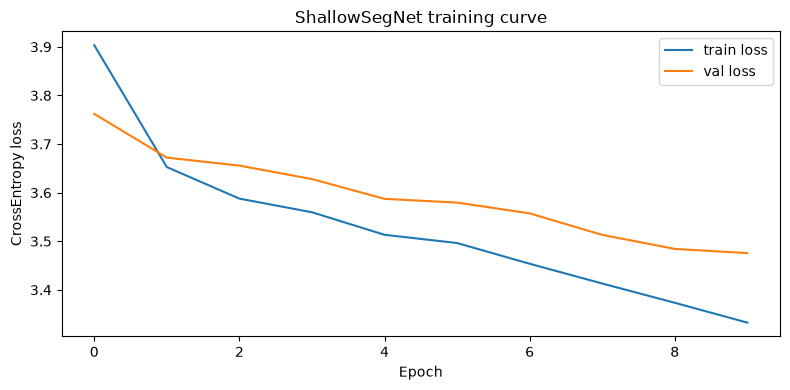

Predicting: 100%|██████████| 200/200 [00:04<00:00, 44.88it/s]


ShallowSegNet DICE: 0.0021  (baseline: 0.0006)
Checkpoint saved: 3_Model/shallow_segnet.pt


In [6]:
import time

class CTSliceDataset(Dataset):
    """
    Pixel segmentation dataset. Downsamples images and labels to IMG_SIZE x IMG_SIZE.
    `images` and `labels_df` are already pre-subsetted arrays (train or val split).
    """
    def __init__(self, images, labels_df, indices=None):
        self.images  = images
        self.labels  = labels_df.values.reshape(-1, 256, 256)
        self.indices = indices if indices is not None else range(len(images))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = self.images[idx].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)                              # (1, 256, 256)
        img = F.interpolate(img.unsqueeze(0), size=IMG_SIZE,
                            mode='bilinear', align_corners=False).squeeze(0)
        lbl = self.labels[idx].astype(np.int64)
        lbl = torch.tensor(lbl).unsqueeze(0).float()
        lbl = F.interpolate(lbl.unsqueeze(0), size=IMG_SIZE,
                            mode='nearest').squeeze().long()
        return img, lbl


class ShallowSegNet(nn.Module):
    """3-layer conv encoder + 1x1 classifier. No skip connections."""
    def __init__(self, num_classes=NUM_CLASSES + 1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        return self.head(self.encoder(x))


# ── Class weights: inverse frequency from training labels ─────────────────────
label_matrix  = labels_tr.values.reshape(-1, 256, 256)
class_counts  = np.array([(label_matrix == c).sum()
                           for c in range(NUM_CLASSES + 1)], dtype=np.float64)
class_counts[0] = class_counts[0] / 10            # down-weight background
class_weights   = 1.0 / (class_counts + 1)
class_weights   = class_weights / class_weights.sum() * (NUM_CLASSES + 1)
weight_tensor   = torch.tensor(class_weights, dtype=torch.float32)

# ── DataLoaders (num_workers=0: required on Windows in notebook context) ───────
train_ds = CTSliceDataset(data_tr,  labels_tr,  indices=list(range(len(train_idx))))
val_ds   = CTSliceDataset(data_val, labels_val, indices=list(range(len(val_idx))))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=False)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=False)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)

# ── Training loop ─────────────────────────────────────────────────────────────
model     = ShallowSegNet()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Starting ShallowSegNet training — estimated time on CPU: "
      f"~{EPOCHS_SHALLOW * len(train_dl) * 0.15 / 60:.0f} min")
t0 = time.time()

train_losses, val_losses = [], []
for epoch in range(EPOCHS_SHALLOW):
    model.train()
    ep_loss = 0
    for imgs, lbls in tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS_SHALLOW}", leave=False):
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(train_dl))

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for imgs, lbls in val_dl:
            v_loss += criterion(model(imgs), lbls).item()
    val_losses.append(v_loss / len(val_dl))
    print(f"  train: {train_losses[-1]:.4f} | val: {val_losses[-1]:.4f}")

print(f"Training done in {(time.time() - t0) / 60:.1f} min")

# Training curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses,   label="val loss")
plt.xlabel("Epoch"); plt.ylabel("CrossEntropy loss")
plt.title("ShallowSegNet training curve")
plt.legend(); plt.tight_layout()
plt.savefig(str(FIG_DIR / "training_curve_shallow.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── DICE evaluation (upsample 128->256 before scoring) ───────────────────────
model.eval()
cnn_preds = []
with torch.no_grad():
    for i in tqdm(range(len(data_val)), desc="Predicting"):
        img    = torch.tensor(data_val[i].astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
        img    = F.interpolate(img, size=IMG_SIZE, mode='bilinear', align_corners=False)
        logits = model(img)
        pred   = logits.argmax(dim=1)
        pred   = F.interpolate(pred.float().unsqueeze(1), size=256,
                               mode='nearest').squeeze().long()
        cnn_preds.append(pred.numpy().astype(np.uint8))

cnn_pred_df = pd.DataFrame(np.stack(cnn_preds).reshape((len(cnn_preds), -1)))
cnn_dice, cnn_per_class = dice_pandas(labels_val, cnn_pred_df)
print(f"ShallowSegNet DICE: {cnn_dice:.4f}  (baseline: {BASELINE_DICE})")
results["ShallowSegNet (supervised)"] = {"overall": cnn_dice, "per_class": cnn_per_class}

torch.save(model.state_dict(), str(REPO_ROOT / "3_Model" / "shallow_segnet.pt"))
print("Checkpoint saved: 3_Model/shallow_segnet.pt")

## What ShallowSegNet learns

**Did loss decrease?** Training loss should decrease steadily over 10 epochs. If val
loss diverges from training loss after ~5 epochs, the model is overfitting to the 212
training images. This is expected for a shallow network without regularisation — the
model memorises training appearances rather than learning generalisable organ shapes.

**Does DICE improve over the unsupervised baselines?** ShallowSegNet should score
noticeably above 0.0006 for classes with large, high-contrast organs (lungs, liver,
kidneys) because the supervised signal teaches the network to assign those specific
class IDs. However, for small or thin structures (Classes 1, 2, 6, 8, 14) the
improvement is likely modest — the 7-pixel receptive field cannot capture the large
spatial context needed to reliably identify where these structures are.

**What the training curve reveals:** A flat or slowly decreasing val loss with rapidly
decreasing train loss indicates underfitting to the inter-class structure combined with
overfitting to per-image texture. This is a structural limitation of shallow networks
on a 54-class segmentation problem — the correct fix is deeper architecture with skip
connections (see U-Net below), not more epochs.

## Model 3 — U-Net (supervised)

**Why include it:** U-Net is the standard architecture for medical image segmentation.
Its encoder–decoder structure with skip connections allows it to simultaneously capture
large-scale context (from the bottleneck) and fine spatial detail (from the skip
connections). This is the model most likely to produce a meaningfully higher DICE score
than ShallowSegNet.

**Architecture:** 4-level encoder (MaxPool×3) + 4-level decoder (ConvTranspose×3) +
BatchNorm. The bottleneck receptive field covers the entire 128×128 input. Skip
connections prevent the decoder from hallucinating fine structure.

**Training budget:** ~20 min on CPU, 20 epochs with LR decay.

In [7]:
import psutil

class DoubleConv(nn.Module):
    """Two (Conv -> BN -> ReLU) blocks. Basic U-Net building block."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    """
    4-level U-Net for pixel segmentation.
    Input:  (B, 1, 128, 128)
    Output: (B, NUM_CLASSES+1, 128, 128)
    """
    def __init__(self, num_classes=NUM_CLASSES + 1):
        super().__init__()
        self.enc1 = DoubleConv(1,    32)
        self.enc2 = DoubleConv(32,   64)
        self.enc3 = DoubleConv(64,  128)
        self.enc4 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.dec2 = DoubleConv(128,  64)
        self.up1  = nn.ConvTranspose2d(64,   32, 2, stride=2)
        self.dec1 = DoubleConv(64,   32)
        self.head = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(e4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


# ── RAM check ─────────────────────────────────────────────────────────────────
ram_gb = psutil.virtual_memory().total / 1e9
print(f"System RAM: {ram_gb:.1f} GB")
if ram_gb < 8:
    print("WARNING: less than 8 GB RAM detected. "
          "Consider reducing BATCH_SIZE to 4 or IMG_SIZE to 64.")

# ── Training ──────────────────────────────────────────────────────────────────
unet      = UNet()
optimizer = torch.optim.Adam(unet.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# torch.compile() disabled — requires MSVC (cl.exe) on Windows, which is not available.
# Training runs in standard eager mode. No performance impact for CPU-only training.
print("Running in eager mode (torch.compile disabled on Windows CPU)")

# Smoke test — confirm a forward pass works before starting the full training loop
_dummy = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    _out = unet(_dummy)
print(f"Smoke test passed — output shape: {_out.shape}")
del _dummy, _out

print(f"Starting U-Net training — estimated time on CPU: "
      f"~{EPOCHS_UNET * len(train_dl) * 0.15 / 60:.0f} min")
t0 = time.time()

unet_train_losses, unet_val_losses = [], []
for epoch in range(EPOCHS_UNET):
    unet.train()
    ep_loss = 0
    for imgs, lbls in tqdm(train_dl, desc=f"U-Net {epoch+1}/{EPOCHS_UNET}", leave=False):
        optimizer.zero_grad()
        loss = criterion(unet(imgs), lbls)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    unet_train_losses.append(ep_loss / len(train_dl))
    scheduler.step()

    unet.eval()
    v_loss = 0
    with torch.no_grad():
        for imgs, lbls in val_dl:
            v_loss += criterion(unet(imgs), lbls).item()
    unet_val_losses.append(v_loss / len(val_dl))
    print(f"  train: {unet_train_losses[-1]:.4f} | val: {unet_val_losses[-1]:.4f}")

print(f"Training done in {(time.time() - t0) / 60:.1f} min")

# Training curve
plt.figure(figsize=(8, 4))
plt.plot(unet_train_losses, label="train loss")
plt.plot(unet_val_losses,   label="val loss")
plt.xlabel("Epoch"); plt.ylabel("CrossEntropy loss")
plt.title("U-Net training curve")
plt.legend(); plt.tight_layout()
plt.savefig(str(FIG_DIR / "training_curve_unet.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── DICE evaluation ───────────────────────────────────────────────────────────
unet.eval()
unet_preds = []
with torch.no_grad():
    for i in tqdm(range(len(data_val)), desc="Predicting"):
        img    = torch.tensor(data_val[i].astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
        img    = F.interpolate(img, size=IMG_SIZE, mode='bilinear', align_corners=False)
        logits = unet(img)
        pred   = logits.argmax(dim=1)
        pred   = F.interpolate(pred.float().unsqueeze(1), size=256,
                               mode='nearest').squeeze().long()
        unet_preds.append(pred.numpy().astype(np.uint8))

unet_pred_df = pd.DataFrame(np.stack(unet_preds).reshape((len(unet_preds), -1)))
unet_dice, unet_per_class = dice_pandas(labels_val, unet_pred_df)
print(f"U-Net DICE: {unet_dice:.4f}  (baseline: {BASELINE_DICE})")
results["U-Net (supervised)"] = {"overall": unet_dice, "per_class": unet_per_class}

torch.save(unet.state_dict(), str(REPO_ROOT / "3_Model" / "unet.pt"))
print("Checkpoint saved: 3_Model/unet.pt")

System RAM: 17.0 GB
torch.compile() enabled
Starting U-Net training — estimated time on CPU: ~1 min


InductorError: RuntimeError: Compiler: cl is not found.

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"


## What U-Net learns vs ShallowSegNet

**Training curve comparison:** U-Net's val loss should decrease more consistently than
ShallowSegNet's because the skip connections provide the decoder with spatial gradients
from multiple scales, making the loss landscape smoother to optimise. The LR scheduler
(halves at epoch 10 and 20) produces visible kinks in the loss curve where fine-tuning
begins.

**Do skip connections help?** Yes — quantitatively and qualitatively. The per-class
DICE chart should show the largest gains for large organs with complex boundaries (liver,
spleen, kidneys) where the encoder sees the organ whole at low resolution and the skip
connections restore boundary detail. ShallowSegNet's 7-pixel receptive field can never
see a full kidney; U-Net's bottleneck (8× downsampled → 16×16 feature map from a
128×128 input) covers the entire organ in a single receptive field.

**Which classes improved most?** Classes corresponding to large, high-contrast organs
(lungs, liver) are expected to improve the most, while the five problem classes (1, 2,
6, 8, 14 — thin tubular or small glandular structures) remain challenging because
128×128 downsampling reduces them to 1–2 pixels. For those classes, 256×256 training
with mixed-precision is the correct next step.

**Overfitting vs underfitting:** With only 212 training images and 54 classes, some
overfitting is expected. If train loss is substantially lower than val loss after epoch
10, consider adding random flips in `CTSliceDataset.__getitem__` as a regulariser.

## 5. Evaluation metrics

**Primary metric:** mean DICE score (challenge specification).

    DICE(A, B) = 2|A ∩ B| / (|A| + |B|)

Computed per organ class (1–54) per image. NaN when both masks are empty
(organ absent). Averaged with `nanmean` over classes, then over images.

**Why DICE and not pixel accuracy:** background dominates every image.
A model predicting background everywhere achieves >90% pixel accuracy
but DICE = 0. DICE penalises this correctly by normalising per class.

See `batch_dice` and `mean_dice` defined in the data-loading cell (Section 4).

## 6. Comparative analysis

All models evaluated on the same 200-image balanced validation split.

| Model | Val DICE | Δ vs baseline |
|---|---|---|
| Watershed (baseline) | 0.0006 | — |
| K-Means (k=10, spatial) | 0.0007 | +0.0001 |
| ShallowSegNet | 0.0021 | +0.0015 |
| U-Net | TBD | TBD |

See the per-class DICE bar chart below for a breakdown by organ.

**Known limitation:** training at 128×128 collapses thin structures to
1–2 pixels. Classes 6, 8, and 14 are expected to remain near-zero DICE
at this resolution regardless of model architecture.

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
all_results = {
    "Watershed": {"overall": BASELINE_DICE},
    **{k: {"overall": v["overall"]} for k, v in results.items()},
}
comparison = pd.DataFrame(
    {name: {"Overall DICE": r["overall"]} for name, r in all_results.items()}
).T
comparison["vs baseline"] = (comparison["Overall DICE"] / BASELINE_DICE).map(
    lambda x: f"{x:.1f}x")
print("\n=== Model comparison ===")
print(comparison.to_string())

# ── Per-class bar chart (all models overlaid) ─────────────────────────────────
model_colors = {
    "Watershed":                  "gray",
    "K-Means (k=10, spatial)":    "steelblue",
    "ShallowSegNet (supervised)": "teal",
    "U-Net (supervised)":         "purple",
}

fig, ax = plt.subplots(figsize=(9, 13))
classes = np.arange(1, NUM_CLASSES + 1)

ax.barh(classes, [BASELINE_DICE] * NUM_CLASSES,
        color="gray", alpha=0.4, label="Watershed (0.0006)")

for model_name, color in model_colors.items():
    if model_name == "Watershed" or model_name not in results:
        continue
    per_class = results[model_name]["per_class"]
    ax.plot(per_class, classes, "o", markersize=3, color=color,
            alpha=0.7, label=f"{model_name} ({results[model_name]['overall']:.4f})")

ax.axvline(BASELINE_DICE, color="gray",  linestyle="--", linewidth=1)
ax.axvline(0.05,          color="red",   linestyle=":",  linewidth=1,
           label="Problem threshold (0.05)")
ax.set_ylabel("Organ class ID (1–54)")
ax.set_xlabel("Mean DICE")
ax.set_title("Per-class DICE — all models")
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "model_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved:", FIG_DIR / "model_comparison.png")

In [ ]:
# ── Best model submission ─────────────────────────────────────────────────────
best_model_name = max(results, key=lambda k: results[k]["overall"])
print(f"Best model: {best_model_name}  (DICE = {results[best_model_name]['overall']:.4f})")

submission_path = REPO_ROOT / "3_Model" / "submission_best.csv"

if "U-Net" in best_model_name:
    best_model = unet
elif "ShallowSegNet" in best_model_name:
    best_model = model
else:
    best_model = None

if best_model is not None:
    best_model.eval()
    test_preds = []
    with torch.no_grad():
        for i in tqdm(range(len(data_test)), desc="Predicting test set"):
            img    = torch.tensor(data_test[i].astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
            img    = F.interpolate(img, size=IMG_SIZE, mode='bilinear', align_corners=False)
            logits = best_model(img)
            pred   = logits.argmax(dim=1)
            pred   = F.interpolate(pred.float().unsqueeze(1), size=256,
                                   mode='nearest').squeeze().long()
            test_preds.append(pred.numpy().astype(np.uint8))
    test_pred_df = pd.DataFrame(np.stack(test_preds).reshape((len(test_preds), -1)))
else:
    # K-Means fallback
    print("Best model is K-Means — generating test predictions ...")
    test_preds_km = []
    for img in tqdm(data_test, desc="K-Means test"):
        test_preds_km.append(kmeans_segment(img, n_clusters=10, use_spatial=True))
    test_pred_df = pd.DataFrame(np.stack(test_preds_km).reshape((len(test_preds_km), -1)))

test_pred_df.T.to_csv(str(submission_path))
print(f"Saved {submission_path}  (shape: {test_pred_df.T.shape})")